In [122]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_DISABLE_MMAP_CACHE"] = "1"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=2"

import sys
import numpy as np
import discovery as ds
import numpy as np
import glob
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', False)
jax.clear_caches()
import jax.numpy as jnp
import functools
from tqdm import tqdm

from enterprise.signals import signal_base

import numpy as np
import scipy.linalg as sl
import scipy.sparse as ss
from sksparse.cholmod import cholesky
from enterprise.signals import signal_base
from enterprise.signals.gp_signals import get_timing_model_basis, BasisGP
from enterprise.signals.parameter import function
from enterprise_extensions import load_feathers


import argparse
import time

import numpy as np  # plain numpy for non-jitted helper pieces

    
from enterprise.signals import selections
import enterprise.signals.parameter as parameter
from enterprise.signals import white_signals
from enterprise_extensions.blocks import common_red_noise_block
from enterprise.signals import gp_signals    
from enterprise.signals import utils
from enterprise_extensions import deterministic
from discovery.deterministic import make_phase_connected_binary

from pathlib import Path

In [123]:
# Set data product directory. The simulation code requires pulsar timing models and data to initialise. 
# In this directory, we have stored these files for a set of pulsars (mimicking the IPTA DR2 dataset, but nonetheless synthetic).

feather_dir = "../data_products/"

### Set up options

In [124]:
# The pulsar term is always injected into the data, this is referring to whether we include it in the model.
pulsar_term = True

# Realisation seed
seed = 1234
rng= np.random.default_rng(seed)
# The number of CW sources to inject
num_cw = 1

# The number of pulsars to use in the analysis (for speed, max=116 available)
Npulsars = 10

In [125]:
# Bookkeeping between the injection and diff likelihood codes
cw_block_names = ["cw" if i == 0 else f"cw{i+1}" for i in range(num_cw)]
disco_suffixes = ["" if i == 0 else f"_{i+1}" for i in range(num_cw)]

### Set up data injection

In [126]:
# Simulation code. Uses the signal objects from enterprise, an input parameter dictionary, and pulsar residuals
# and returns simulated residuals with signals drawn from the Gaussian processes defined in the PTA object.

def simulate(pta, params, sparse_cholesky=True):
    """Simulate code with enterprise (instead of libstempo/PINT)"""
    delays, ndiags, fmats, phis = (pta.get_delay(params=params),
                                   pta.get_ndiag(params=params),
                                   pta.get_basis(params=params),
                                   pta.get_phi(params=params))

    gpresiduals = []
    if pta._commonsignals:
        if sparse_cholesky:
            cf = cholesky(ss.csc_matrix(phis))
            gp = np.zeros(phis.shape[0])
            gp[cf.P()] = np.dot(cf.L().toarray(), np.random.randn(phis.shape[0]))
        else:
            gp = np.dot(sl.cholesky(phis, lower=True), np.random.randn(phis.shape[0]))

        i = 0
        for fmat in fmats:
            j = i + fmat.shape[1]
            gpresiduals.append(np.dot(fmat, gp[i:j]))
            i = j

        assert len(gp) == i
    else:
        for fmat, phi in zip(fmats, phis):
            if phi is None:
                gpresiduals.append(0)
            elif phi.ndim == 1:
                gpresiduals.append(np.dot(fmat, np.sqrt(phi) * np.random.randn(phi.shape[0])))
            else:
                raise NotImplementedError

    whiteresiduals = []
    for delay, ndiag in zip(delays, ndiags):
        if ndiag is None:
            whiteresiduals.append(0)
        elif isinstance(ndiag, signal_base.ShermanMorrison):
            # this code is very slow...
            n = np.diag(ndiag._nvec)
            for j,s in zip(ndiag._jvec, ndiag._slices):
                n[s,s] += j
            whiteresiduals.append(delay + np.dot(sl.cholesky(n, lower=True), np.random.randn(n.shape[0])))
        elif ndiag.ndim == 1:
            whiteresiduals.append(delay + np.sqrt(ndiag) * np.random.randn(ndiag.shape[0]))
        else:
            raise NotImplementedError

    return [np.array(g + w) for g, w in zip(gpresiduals, whiteresiduals)]

def set_residuals(psr, y):
    psr._residuals[psr._isort] = y

@function
def tm_prior(weights, toas, variance=1e40):
    return weights * variance * len(toas)

def TimingModel(coefficients=False, name="linear_timing_model",
                use_svd=False, normed=True, prior_variance=1e40):
    """Class factory for marginalized linear timing model signals."""

    basis = get_timing_model_basis(use_svd, normed)
    prior = tm_prior(variance=prior_variance)

    BaseClass = BasisGP(prior, basis, coefficients=coefficients, name=name)

    class TimingModel(BaseClass):
        signal_type = "basis"
        signal_name = "linear timing model"
        signal_id = name + "_svd" if use_svd else name

    return TimingModel


In [127]:
# Load the pulsars data products as Enterprise Pulsar objects
# Any DMX or p_dist errors can be ignored.
psrs = load_feathers.load_feathers_from_folder(feather_dir)

FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J0030+0451.feather.
FeatherPulsar.read_feather:

In [128]:
##### This code builds a simple PTA model for the simulated data including: 
# instrumental white noise, 
# pulsar intrinsic red noise (radio-frequency independent),
# a Hellings-Downs correlated gravitational wave background signal 
# and N continuous wave sources.


# The _pdist attribute is used by enterprise to store the pulsar distance. 
# Here, we back this up to allow us to vary it later. We also wipe the residuals to zero.
for psr in psrs:
    psr._pdist = psr.pdist
    psr.residuals = np.array(psr.toas) * 0.0

tmin = [p.toas.min() for p in psrs]
tmax = [p.toas.max() for p in psrs]
Tspan = np.max(tmax) - np.min(tmin)


selection = selections.Selection(selections.by_backend)
efac = parameter.Constant(1)
equad = parameter.Constant(-8)

log10_A_red = parameter.Uniform(-18, -11)
gamma_red = parameter.Uniform(0, 7)
log10_A_gw = parameter.Uniform(-18,-11)('gwb_log10_A')
gamma_gw = parameter.Uniform(0,7)('gwb_gamma')

# Number of Fourier components for red noise and GWB
components = 30

tm = TimingModel(coefficients=False, name="linear_timing_model",
                use_svd=False, normed=True, prior_variance=1e-14)
models = []
for p in psrs:
    s = tm

    ef = white_signals.MeasurementNoise(efac=efac, selection=selection)
    s += ef

    eq = white_signals.TNEquadNoise(log10_tnequad=equad, selection=selection)
    s += eq

    pl = utils.powerlaw(log10_A=log10_A_red, gamma=gamma_red)
    rn = gp_signals.FourierBasisGP(spectrum=pl, components=components, Tspan=Tspan, name="rednoise")
    s += rn

    ## HD Correlated signal
    crn = common_red_noise_block(psd='powerlaw', prior='log-uniform',
                        components=components, orf='hd', name='gwb')

    s += crn

    # CW sources
    # This is a phase-distance connected circular binary model that evolves according to GR. 
    # Both the Earth and pulsar terms are included.
    
    for name in cw_block_names:
        s += deterministic.cw_block_circ(
            amp_prior="log-uniform",
            dist_prior=None,
            skyloc=None,
            log10_fgw=None,
            psrTerm=True,
            phase_connected=True,
            discoclone=False,
            name=name,
        )

    models.append(s(p))
    print(p.name)
    
pta = signal_base.PTA(models)

pta.set_default_params({})

B1855+09
B1937+21
B1953+29
J0023+0923
J0030+0451
J0125-2327
J0340+4130
J0406+3039
J0437-4715
J0509+0856
J0557+1551
J0605+3757
J0610-2100
J0613-0200
J0614-3329
J0636+5128
J0636-3044
J0645+5158
J0709+0458
J0711-6830
J0740+6620
J0751+1807
J0900-3144
J0931-1902
J0955-6150
J1012+5307
J1012-4235
J1017-7156
J1022+1001
J1024-0719
J1036-8317
J1045-4509
J1101-6424
J1103-5403
J1125+7819
J1125-5825
J1125-6014
J1216-6410
J1312+0051
J1327-0755
J1421-4409
J1431-5740
J1435-6100
J1446-4701
J1453+1902
J1455-3330
J1525-5545
J1543-5149
J1545-4550
J1547-5709
J1600-3053
J1603-7202
J1614-2230
J1629-6902
J1630+3734
J1640+2224
J1643-1224
J1652-4838
J1653-2054
J1658-5324
J1705-1903
J1708-3506
J1713+0747
J1719-1438
J1721-2457
J1730-2304
J1732-5049
J1737-0811
J1738+0333
J1741+1351
J1744-1134
J1745+1017
J1747-4036
J1751-2857
J1756-2251
J1757-5322
J1801-1417
J1802-2124
J1804-2717
J1811-2405
J1824-2452A
J1825-0319
J1832-0836
J1843-1113
J1853+1303
J1902-5105
J1903+0327
J1903-7051
J1909-3744
J1910+1256
J1911+1347
J191

### Decide what to inject and include in this dictionary

In [129]:

# This is the dictionary of parameters used to simulate the data.
# Rednoise is drawn from realistic parameter ranges based on PTA analyses.
# GWB is fixed at a reasonable level.
# CW sources are drawn from wide priors describing the possible source populations.
#### NB: Most CWs that PTAs could detect are expected to be Mc~10^10 and 5-15 nHz frequencies, 
#### described here is what is generally used in blind searches.

enterprise_params ={}
enterprise_params.update({p: -20 for p in pta.param_names if 'rednoise_log10_A' in p})
enterprise_params.update({p: 3 for p in pta.param_names if 'rednoise_gamma' in p})

for psr in psrs:
    enterprise_params.update({p: psr.pdist[0] for p in pta.param_names if psr.name+'_cw_p_dist' in p})

#enterprise_params.update({'gwb_gamma': 4.333, 'gwb_log10_A': -17.5})

for name in cw_block_names:
    enterprise_params.update(
        {
            f"{name}_cos_inc": np.random.uniform(-1.0,1.0), # cosine of Inclination of GW source [radians]
            f"{name}_log10_fgw": np.random.uniform(-9.0,-7.0), # log10 of Frequency of GW (twice the orbital frequency) [Hz]
            f"{name}_log10_h": np.random.uniform(-18.0, -11.0), # log10 of GW strain amplitude
            f"{name}_log10_mc": np.random.uniform(6.0, 10.0), # log10 of chirp mass [solar masses]
            f"{name}_gwphi": np.random.uniform(0, 2 * np.pi), # Azimuthal angle of GW source in celestial coords [radians]
            f"{name}_cos_gwtheta": np.random.uniform(-1, 1), # Cosine of Polar angle of GW source in celestial coords [radians]
            f"{name}_phase0": np.random.uniform(0, 2 * np.pi), # Initial GW phase of source [radians]
            f"{name}_psi": np.random.uniform(0, np.pi), # Polarization angle of GW source [radians]
        }
    )


# Bookkeeping dictionaries to map between enterprise and discovery parameter names
temp_dict = dict(enterprise_params)
reverse_temp_dict = {k: k for k in enterprise_params}

for name, suffix in zip(cw_block_names, disco_suffixes):
    for key, val in enterprise_params.items():
        if key.startswith(f"{name}_"):
            base = key.replace(name, "cw", 1)
            disco_key = f"{base}{suffix}"
            temp_dict[disco_key] = val
            reverse_temp_dict[disco_key] = key

In [130]:
# Reload data for diff likelihood analysis

disco_psrs = [ds.Pulsar.read_feather(f) for f in sorted(glob.glob(feather_dir + "*.feather"))][:int(Npulsars)]
for psr in disco_psrs:
    psr.toaerrs = np.full_like(psr.toas, 1e-6, dtype=np.float64) # Set TOA errors to 1 microsecond

In [131]:

# white-noise parameters fixed once
noisedict = {
    psr.name + "_KAT_MKBF_efac": 1.0
    for psr in disco_psrs
}
noisedict.update({
    psr.name + "_KAT_MKBF_log10_ecorr": -8.0
    for psr in disco_psrs
})
noisedict.update({
    psr.name + "_KAT_MKBF_log10_t2equad": -8.0
    for psr in disco_psrs
})

noise_terms = {
    psr.name: ds.makenoise_measurement(psr, noisedict=noisedict)
    for psr in disco_psrs
}
timing_terms = {
    psr.name: ds.makegp_timing(psr, variance=1e-14)
    for psr in disco_psrs
}


In [212]:
import numpy as np
import jax
import jax.numpy as jnp
from dataclasses import dataclass

@dataclass
class PiecewiseInterpCache:
    # arrays are float32 unless noted
    toas: jnp.ndarray        # (Ntoa,) absolute seconds
    seg_id: jnp.ndarray      # (Ntoa,) int32 segment index for each TOA
    x_toas: jnp.ndarray      # (Ntoa,) normalized coord in [0,1] within its segment
    t0s: jnp.ndarray         # (B,) float32 segment start times (sec)
    Ts: jnp.ndarray          # (B,) float32 segment durations (sec)
    x_grid: jnp.ndarray      # (Ng,) float32 common grid [0,1]
    t_grid: jnp.ndarray      # (B, Ng) float32 absolute times for each segment grid
    B: int
    Ng: int

def build_piecewise_interp_cache(psr, B=16, Ng=512):
    toas = np.asarray(psr.toas, dtype=np.float64)
    t0 = toas.min()
    t1 = toas.max()
    # segment edges in absolute time
    edges = np.linspace(t0, t1, B+1, dtype=np.float64)

    # assign each TOA to a segment
    seg_id = np.searchsorted(edges, toas, side="right") - 1
    seg_id = np.clip(seg_id, 0, B-1).astype(np.int32)

    # per-seg start and duration
    t0s = edges[:-1].astype(np.float32)
    t1s = edges[1:].astype(np.float32)
    Ts = (t1s - t0s).astype(np.float32)

    # normalized x within segment
    x_toas = ((toas.astype(np.float32) - t0s[seg_id]) / Ts[seg_id]).astype(np.float32)
    x_toas = np.clip(x_toas, 0.0, 1.0)

    # common normalized grid [0,1]
    x_grid = np.linspace(0.0, 1.0, Ng, endpoint=True, dtype=np.float32)

    # per-seg grid in absolute seconds: shape (B,Ng)
    t_grid = (t0s[:, None] + Ts[:, None] * x_grid[None, :]).astype(np.float32)

    return PiecewiseInterpCache(
        toas=jnp.asarray(toas.astype(np.float32)),
        seg_id=jnp.asarray(seg_id),
        x_toas=jnp.asarray(x_toas),
        t0s=jnp.asarray(t0s),
        Ts=jnp.asarray(Ts),
        x_grid=jnp.asarray(x_grid),
        t_grid=jnp.asarray(t_grid),
        B=B,
        Ng=Ng
    )

import jax
import jax.numpy as jnp

@jax.jit
def interp_cubic_uniform(y_grid, xq):
    """
    Catmull-Rom cubic interpolation on a uniform grid x in [0,1].
    y_grid: (Ng,)
    xq: scalar in [0,1]
    """
    Ng = y_grid.shape[0]
    # map xq to fractional index
    u = xq * (Ng - 1)
    i = jnp.floor(u).astype(jnp.int32)
    t = u - i

    # clamp indices for i-1, i, i+1, i+2
    i0 = jnp.clip(i - 1, 0, Ng - 1)
    i1 = jnp.clip(i,     0, Ng - 1)
    i2 = jnp.clip(i + 1, 0, Ng - 1)
    i3 = jnp.clip(i + 2, 0, Ng - 1)

    p0 = y_grid[i0]
    p1 = y_grid[i1]
    p2 = y_grid[i2]
    p3 = y_grid[i3]

    # Catmull-Rom spline
    a = 0.5 * (2*p1)
    b = 0.5 * (-p0 + p2)
    c = 0.5 * (2*p0 - 5*p1 + 4*p2 - p3)
    d = 0.5 * (-p0 + 3*p1 - 3*p2 + p3)

    return a + b*t + c*t*t + d*t*t*t

@jax.jit
def interp_piecewise_cubic(y_grid_by_seg, seg_id, x_toas):
    """
    y_grid_by_seg: (B,Ng)
    seg_id: (Ntoa,)
    x_toas: (Ntoa,)
    """
    return jax.vmap(lambda s, xq: interp_cubic_uniform(y_grid_by_seg[s], xq))(seg_id, x_toas)


@jax.jit
def interp_piecewise(x_grid, y_grid_by_seg, seg_id, x_toas):
    """
    y_grid_by_seg: (B,Ng)
    seg_id: (Ntoa,)
    x_toas: (Ntoa,)
    returns y_toas: (Ntoa,)
    """
    # vmap interp over segments then select
    def interp_one(seg_y, xq):
        return jnp.interp(xq, x_grid, seg_y)

    # For each TOA i: pick its segment s = seg_id[i], interpolate y_grid_by_seg[s] at x_toas[i]
    return jax.vmap(lambda s, xq: interp_one(y_grid_by_seg[s], xq))(seg_id, x_toas)

class MultiSourceDelayFastInterpPiecewise:
    global_params = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw",
                     "log10_h", "phase0", "psi")

    def __init__(self, psr, n_sources, include_pterm, B=16, Ng=512):
        self.psr = psr
        self.n_sources = n_sources
        self.include_pterm = include_pterm
        self.single_source = make_phase_connected_binary(pulsarterm=self.include_pterm)

        self.cache = build_piecewise_interp_cache(psr, B=B, Ng=Ng)

        params = []
        for idx in range(n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            for key in self.global_params:
                name = f"cw_{key}{suffix}"
                if name not in params:
                    params.append(name)
        if self.include_pterm:
            params.append(f"{self.psr.name}_cw_u_dist")
        self.params = params

    def __call__(self, params):
        total = 0.0
        for idx in range(self.n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            kwargs = {
                "cos_gwtheta": params[f"cw_cos_gwtheta{suffix}"],
                "gwphi": params[f"cw_gwphi{suffix}"],
                "cos_inc": params[f"cw_cos_inc{suffix}"],
                "log10_mc": params[f"cw_log10_mc{suffix}"],
                "log10_fgw": params[f"cw_log10_fgw{suffix}"],
                "log10_h": params[f"cw_log10_h{suffix}"],
                "phase0": params[f"cw_phase0{suffix}"],
                "psi": params[f"cw_psi{suffix}"],
            }
            if self.include_pterm:
                u = params[f"{self.psr.name}_cw_u_dist"]
                kwargs["p_dist"] = jax.nn.softplus(u) + 1e-6

            # Evaluate waveform on (B,Ng) grid points
            # Flatten grid for waveform call, then reshape
            t_grid_flat = self.cache.t_grid.reshape(-1)
            r_flat = self.single_source(t_grid_flat, self.psr.pos, **kwargs)
            r_grid = r_flat.reshape(self.cache.B, self.cache.Ng)

            # Interpolate to TOAs segment-wise
            r_toas = interp_piecewise_cubic(r_grid, self.cache.seg_id, self.cache.x_toas)
            # r_toas = interp_piecewise(self.cache.x_grid, r_grid, self.cache.seg_id, self.cache.x_toas)
            total += r_toas
        return total

In [213]:
@jax.jit
def rfft_to_trig_coeffs(r_grid):
    """
    Given r_grid sampled on a uniform grid of length Ng over one period,
    return (a0, a, b) such that:
      r(t) ≈ a0 + Σ_{k=1..K} [a_k cos(2πk x) + b_k sin(2πk x)]
    where x = (t - t0)/T.

    r_grid: (Ng,) real
    returns:
      a0: scalar
      a: (K,)
      b: (K,)
    """
    Ng = r_grid.shape[0]
    R = jnp.fft.rfft(r_grid)  # complex, shape (Ng//2+1,)

    # DFT normalization: numpy/jax rfft uses unnormalized forward transform.
    # For real Fourier series coefficients on [0, T]:
    # a0 = Re(R0)/Ng
    # a_k = 2*Re(Rk)/Ng
    # b_k = -2*Im(Rk)/Ng    (minus sign matches cos+sin convention)
    a0 = jnp.real(R[0]) / Ng
    # we’ll slice k=1..K later outside this function
    return a0, R

In [214]:

# Wrapper code to use N continuous wave sources in the diff likelihood.
class MultiSourceDelay:
    global_params = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw",
                     "log10_h", "phase0", "psi")

    def __init__(self, psr, n_sources, include_pterm):
        self.psr = psr
        self.n_sources = n_sources
        self.include_pterm = include_pterm
        self.single_source = make_phase_connected_binary(pulsarterm=self.include_pterm)

        params = []

        # CW global parameters shared across pulsars
        for idx in range(n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            for key in self.global_params:
                name = f"cw_{key}{suffix}"
                if name not in params:
                    params.append(name)

        # One unconstrained distance parameter per pulsar (strict phase-linked)
        if self.include_pterm:
            params.append(f"{self.psr.name}_cw_u_dist")

        self.params = params

    def __call__(self, params):
        total = 0.0
        for idx in range(self.n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"

            kwargs = {
                "cos_gwtheta": params[f"cw_cos_gwtheta{suffix}"],
                "gwphi": params[f"cw_gwphi{suffix}"],
                "cos_inc": params[f"cw_cos_inc{suffix}"],
                "log10_mc": params[f"cw_log10_mc{suffix}"],
                "log10_fgw": params[f"cw_log10_fgw{suffix}"],
                "log10_h": params[f"cw_log10_h{suffix}"],
                "phase0": params[f"cw_phase0{suffix}"],
                "psi": params[f"cw_psi{suffix}"],
            }

            if self.include_pterm:
                u = params[f"{self.psr.name}_cw_u_dist"]
                p_dist = jax.nn.softplus(u) + 1e-6  # kpc, strictly positive
                kwargs["p_dist"] = p_dist

            total += self.single_source(self.psr.toas, self.psr.pos, **kwargs)

        return total

In [215]:
@jax.jit
def rfft_coeffs(r_grid):
    Ng = r_grid.shape[0]
    R = jnp.fft.rfft(r_grid)
    a0 = jnp.real(R[0]) / Ng
    return a0, R

class MultiSourceDelayFastFourier:
    global_params = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw",
                     "log10_h", "phase0", "psi")

    def __init__(self, psr, n_sources, include_pterm, K=128, Ng=1024):
        self.psr = psr
        self.n_sources = n_sources
        self.include_pterm = include_pterm
        self.single_source = make_phase_connected_binary(pulsarterm=self.include_pterm)

        self.cache = build_fourier_det_cache_abs(psr, K=K, Ng=Ng)

        params = []
        for idx in range(n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            for key in self.global_params:
                name = f"cw_{key}{suffix}"
                if name not in params:
                    params.append(name)

        if self.include_pterm:
            params.append(f"{self.psr.name}_cw_u_dist")

        self.params = params

    def __call__(self, params):
        total = 0.0
        for idx in range(self.n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            kwargs = {
                "cos_gwtheta": params[f"cw_cos_gwtheta{suffix}"],
                "gwphi": params[f"cw_gwphi{suffix}"],
                "cos_inc": params[f"cw_cos_inc{suffix}"],
                "log10_mc": params[f"cw_log10_mc{suffix}"],
                "log10_fgw": params[f"cw_log10_fgw{suffix}"],
                "log10_h": params[f"cw_log10_h{suffix}"],
                "phase0": params[f"cw_phase0{suffix}"],
                "psi": params[f"cw_psi{suffix}"],
            }

            if self.include_pterm:
                u = params[f"{self.psr.name}_cw_u_dist"]
                kwargs["p_dist"] = jax.nn.softplus(u) + 1e-6

            # Evaluate on ABSOLUTE grid times (same units as psr.toas)
            r_grid = self.single_source(self.cache.t_grid, self.psr.pos, **kwargs)

            a0, R = rfft_coeffs(r_grid)
            K = self.cache.K

            a = 2.0 * jnp.real(R[1:K+1]) / self.cache.Ng
            b = -2.0 * jnp.imag(R[1:K+1]) / self.cache.Ng

            r_toas = a0 + self.cache.C @ a + self.cache.S @ b
            total += r_toas

        return total

In [216]:
class MultiSourceDelayFastLS:
    global_params = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw",
                     "log10_h", "phase0", "psi")

    def __init__(self, psr, n_sources, include_pterm, K=128, Ng=1024):
        self.psr = psr
        self.n_sources = n_sources
        self.include_pterm = include_pterm
        self.single_source = make_phase_connected_binary(pulsarterm=self.include_pterm)

        self.cache = build_fourier_ls_cache_norm(psr, K=K, Ng=Ng)

        params = []
        for idx in range(n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            for key in self.global_params:
                name = f"cw_{key}{suffix}"
                if name not in params:
                    params.append(name)

        if self.include_pterm:
            params.append(f"{self.psr.name}_cw_u_dist")
        self.params = params

    def __call__(self, params):
        total = 0.0
        for idx in range(self.n_sources):
            suffix = "" if idx == 0 else f"_{idx+1}"
            kwargs = {
                "cos_gwtheta": params[f"cw_cos_gwtheta{suffix}"],
                "gwphi": params[f"cw_gwphi{suffix}"],
                "cos_inc": params[f"cw_cos_inc{suffix}"],
                "log10_mc": params[f"cw_log10_mc{suffix}"],
                "log10_fgw": params[f"cw_log10_fgw{suffix}"],
                "log10_h": params[f"cw_log10_h{suffix}"],
                "phase0": params[f"cw_phase0{suffix}"],
                "psi": params[f"cw_psi{suffix}"],
            }
            if self.include_pterm:
                u = params[f"{self.psr.name}_cw_u_dist"]
                kwargs["p_dist"] = jax.nn.softplus(u) + 1e-6

            # Evaluate waveform on absolute grid times (physics unchanged)
            r_grid = self.single_source(self.cache.t_grid, self.psr.pos, **kwargs)  # (Ng,)

            # LS coefficients: [a0, a1..aK, b1..bK]
            coeffs = self.cache.P @ r_grid  # (2K+1,)
            a0 = coeffs[0]
            a = coeffs[1:1+self.cache.K]
            b = coeffs[1+self.cache.K:]

            r_toas = a0 + self.cache.C_toas @ a + self.cache.S_toas @ b
            total += r_toas

        return total

In [217]:
# Get Tspan of pulsars being used
T = ds.getspan(disco_psrs)

# Set up common GPs for intrinsic pulsar red noise and GWB
common_gp = ds.makecommongp_fourier(disco_psrs, ds.powerlaw, 30, T, name="rednoise")
# global_gp = ds.makeglobalgp_fourier(
#     disco_psrs,
#     ds.powerlaw,
#     ds.hd_orf,
#     30,
#     T,
#     name="gwb",
# )

In [218]:
def build_likelihood(residual_map):
    pulsar_likes = [
        ds.PulsarLikelihood(
            [
                np.array(residual_map[psr.name], copy=True),
                noise_terms[psr.name],
                timing_terms[psr.name],  # remove if you want
                MultiSourceDelayFastFourier(psr, num_cw, include_pterm=pulsar_term, K=64, Ng=512),
            ]
        )
        for psr in disco_psrs
    ]

    fml = ds.ArrayLikelihood(
        pulsar_likes,
        commongp=common_gp if common_gp is not None else None,
        globalgp=global_gp if "global_gp" in globals() else None,
    )
    logl = fml.logL

    # Build defaults for *all* logl.params
    sorted_dict = {}
    for k in logl.params:
        if k in temp_dict:
            sorted_dict[k] = temp_dict[k]
        else:
            # defaults for newly introduced parameters
            if k.endswith("_cw_u_dist"):
                # init so softplus(u) ~ 1 kpc
                sorted_dict[k] = float(np.log(np.expm1(1.0)))
            else:
                sorted_dict[k] = 0.0

    # CRITICAL: use logl.params ordering, not dict keys
    param_keys = list(logl.params)
    base_vals = jnp.array([sorted_dict[k] for k in param_keys], dtype=jnp.float64)

    return logl, param_keys, base_vals

In [219]:
# Simulate the data with enterprise
sim_resids = simulate(pta, enterprise_params, sparse_cholesky=True)
# Map pulsar names to their residuals
name_to_resid = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}

In [220]:
logl, keys, base_values = build_likelihood(name_to_resid)
param_keys = keys
print([k for k in param_keys if k.endswith("_cw_u_dist")])

['B1855+09_cw_u_dist', 'B1937+21_cw_u_dist', 'B1953+29_cw_u_dist', 'J0023+0923_cw_u_dist', 'J0030+0451_cw_u_dist', 'J0125-2327_cw_u_dist', 'J0340+4130_cw_u_dist', 'J0406+3039_cw_u_dist', 'J0437-4715_cw_u_dist', 'J0509+0856_cw_u_dist']


/tmp/ipykernel_2504095/988735458.py:23: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  toas = jnp.asarray(psr.toas, dtype=jnp.float64)  # keep float64 here for now
/tmp/ipykernel_2504095/3211174667.py:36: UserWarning: Explicitly requested dtype float64 requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  base_vals = jnp.array([sorted_dict[k] for k in param_keys], dtype=jnp.float64)


In [221]:
idx_map = {k: i for i, k in enumerate(param_keys)}

U_DIST_KEYS = [f"{psr.name}_cw_u_dist" for psr in disco_psrs]
missing = [k for k in U_DIST_KEYS if k not in idx_map]
if missing:
    raise RuntimeError(f"Missing u_dist parameters in param_keys: {missing}")

U_DIST_IDXS = jnp.array([idx_map[k] for k in U_DIST_KEYS], dtype=jnp.int32)

print("u_dist keys:", U_DIST_KEYS)
print("Any *_cw_u_dist params?", [k for k in param_keys if k.endswith("_cw_u_dist")])

u_dist keys: ['B1855+09_cw_u_dist', 'B1937+21_cw_u_dist', 'B1953+29_cw_u_dist', 'J0023+0923_cw_u_dist', 'J0030+0451_cw_u_dist', 'J0125-2327_cw_u_dist', 'J0340+4130_cw_u_dist', 'J0406+3039_cw_u_dist', 'J0437-4715_cw_u_dist', 'J0509+0856_cw_u_dist']
Any *_cw_u_dist params? ['B1855+09_cw_u_dist', 'B1937+21_cw_u_dist', 'B1953+29_cw_u_dist', 'J0023+0923_cw_u_dist', 'J0030+0451_cw_u_dist', 'J0125-2327_cw_u_dist', 'J0340+4130_cw_u_dist', 'J0406+3039_cw_u_dist', 'J0437-4715_cw_u_dist', 'J0509+0856_cw_u_dist']


In [222]:
print("Any *_cw_u_dist params?", [k for k in param_keys if k.endswith("_cw_u_dist")])

Any *_cw_u_dist params? ['B1855+09_cw_u_dist', 'B1937+21_cw_u_dist', 'B1953+29_cw_u_dist', 'J0023+0923_cw_u_dist', 'J0030+0451_cw_u_dist', 'J0125-2327_cw_u_dist', 'J0340+4130_cw_u_dist', 'J0406+3039_cw_u_dist', 'J0437-4715_cw_u_dist', 'J0509+0856_cw_u_dist']


In [223]:


KPC_OVER_C_S = 3.085677581491367e19 / 299792458.0  # 1 kpc / c in seconds (~1.029e11)

def omega_hat_from_cosgwtheta_gwphi(cos_gwtheta, gwphi):
    """
    Convert (cos_gwtheta, gwphi) to a unit vector \hat{Omega}.
    Convention: theta is polar angle from +z, phi is azimuth.
    """
    cos_th = cos_gwtheta
    sin_th = jnp.sqrt(jnp.clip(1.0 - cos_th**2, 0.0, 1.0))
    return jnp.array([sin_th * jnp.cos(gwphi),
                      sin_th * jnp.sin(gwphi),
                      cos_th], dtype=jnp.float64)

def wrap_spacing_kpc_for_psrs(cw_cos_gwtheta, cw_gwphi, cw_log10_fgw, psr_pos_unitvecs):
    """
    Return Delta L_wrap (kpc) for each pulsar, given current CW params.
    psr_pos_unitvecs: array shape (Np, 3), unit vectors \hat{p}_alpha.
    """
    fgw = 10.0 ** cw_log10_fgw  # Hz
    omega_hat = omega_hat_from_cosgwtheta_gwphi(cw_cos_gwtheta, cw_gwphi)  # (3,)
    kappa = 1.0 + jnp.dot(psr_pos_unitvecs, omega_hat)  # (Np,)
    # Avoid division by ~0 when kappa -> 0
    kappa = jnp.clip(kappa, 1e-3, None)
    dL = 1.0 / (fgw * kappa * KPC_OVER_C_S)  # kpc
    return dL

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2504095/319465566.py:4: SyntaxWarning: invalid escape sequence '\h'
  """
/tmp/ipykernel_2504095/319465566.py:15: SyntaxWarning: invalid escape sequence '\h'
  """


In [224]:
ent_by_name = {p.name: p for p in psrs}  # enterprise pulsars

dist_mu = []
dist_sig = []
for dpsr in disco_psrs:
    ep = ent_by_name[dpsr.name]
    mu = float(ep.pdist[0])
    sig = float(ep.pdist[1]) if len(ep.pdist) > 1 else 0.5
    if not np.isfinite(sig) or sig <= 0:
        sig = 0.5
    dist_mu.append(mu)
    dist_sig.append(sig)

dist_mu = jnp.array(dist_mu, dtype=jnp.float64)
dist_sig = jnp.array(dist_sig, dtype=jnp.float64)

EPS_DIST = 1e-6

/tmp/ipykernel_2504095/781392996.py:14: UserWarning: Explicitly requested dtype float64 requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  dist_mu = jnp.array(dist_mu, dtype=jnp.float64)
/tmp/ipykernel_2504095/781392996.py:15: UserWarning: Explicitly requested dtype float64 requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  dist_sig = jnp.array(dist_sig, dtype=jnp.float64)


In [225]:
@jax.jit
def logprior_u_dist(x_array):
    u = x_array[U_DIST_IDXS]
    p_dist = jax.nn.softplus(u) + EPS_DIST

    # Gaussian prior on physical distance
    z = (p_dist - dist_mu) / dist_sig
    logp_pdist = -0.5 * jnp.sum(z * z) - jnp.sum(jnp.log(dist_sig))  # constant omitted

    # Jacobian: dp/du = sigmoid(u)
    log_jac = jnp.sum(jnp.log(jax.nn.sigmoid(u)))

    return logp_pdist + log_jac

In [226]:
def logl_wrapped(x_array):
    params = {k: v for k, v in zip(param_keys, x_array)}
    return logl(params)

logl_fn = jax.jit(logl_wrapped)

@jax.jit
def logpost_fn(x_array):
    return logl_fn(x_array) + logprior_u_dist(x_array)

def potential_fn(x_array):
    return -logpost_fn(x_array)

In [227]:
def inv_softplus(y):
    return jnp.log(jnp.expm1(y))

base_values_u = jnp.array(base_values, copy=True)
u0 = inv_softplus(jnp.maximum(dist_mu - EPS_DIST, 1e-6))
base_values_u = base_values_u.at[U_DIST_IDXS].set(u0)

In [228]:
# Build a definitely-nonzero CW parameter set (forced test)
params_test = {k: v for k, v in zip(param_keys, base_values_u)}

params_test["cw_log10_h"] = -12.0
params_test["cw_log10_fgw"] = -8.0
params_test["cw_log10_mc"] = 9.0
params_test["cw_cos_gwtheta"] = 0.1
params_test["cw_gwphi"] = 1.0
params_test["cw_cos_inc"] = 0.2
params_test["cw_psi"] = 0.7
params_test["cw_phase0"] = 0.3

# Set all pulsar distances to ~1 kpc in u_dist space
u_1kpc = float(np.log(np.expm1(1.0)))
for psr in disco_psrs:
    params_test[f"{psr.name}_cw_u_dist"] = u_1kpc

psr0 = disco_psrs[0]
slow = MultiSourceDelay(psr0, num_cw, include_pterm=pulsar_term)
r_slow = slow(params_test)

In [229]:
psr0 = disco_psrs[0]
slow = MultiSourceDelay(psr0, num_cw, include_pterm=pulsar_term)

for (B, Ng) in [(8,256), (16,256), (16,512), (32,256)]:
    fast = MultiSourceDelayFastInterpPiecewise(psr0, num_cw, include_pterm=pulsar_term, B=B, Ng=Ng)
    r_fast = fast(params_test)
    diff = np.array(r_slow - r_fast)
    err = np.sqrt(np.mean(diff**2)) / (np.sqrt(np.mean(np.array(r_slow)**2)) + 1e-30)
    print("B", B, "Ng", Ng, "rel RMS", f"{err:.3e}", "max|diff|", f"{np.max(np.abs(diff)):.3e}")

B 8 Ng 256 rel RMS 2.477e-02 max|diff| 8.112e-08
B 16 Ng 256 rel RMS 1.708e-02 max|diff| 7.142e-08
B 16 Ng 512 rel RMS 9.724e-03 max|diff| 2.990e-08
B 32 Ng 256 rel RMS 1.243e-02 max|diff| 4.397e-08


In [170]:
r_slow = slow(params0)
arr = np.array(r_slow)
print("slow max|r|:", arr.max(), np.abs(arr).max())
print("slow min/max:", arr.min(), arr.max())

slow max|r|: 0.0 0.0
slow min/max: 0.0 0.0


In [171]:
params_test = dict(params0)
params_test["cw_log10_h"] = -12.0
params_test["cw_log10_fgw"] = -8.0
params_test["cw_log10_mc"] = 9.0
params_test["cw_cos_gwtheta"] = 0.1
params_test["cw_gwphi"] = 1.0
params_test["cw_cos_inc"] = 0.2
params_test["cw_psi"] = 0.7
params_test["cw_phase0"] = 0.3
for psr in disco_psrs:
    params_test[f"{psr.name}_cw_u_dist"] = float(np.log(np.expm1(1.0)))  # p_dist ~1 kpc

r_slow2 = slow(params_test)
arr2 = np.array(r_slow2)
print("forced slow max|r|:", float(np.max(np.abs(arr2))))
print("forced slow RMS:", float(np.sqrt(np.mean(arr2**2))))

forced slow max|r|: 2.028954895649804e-06
forced slow RMS: 6.966118917262065e-07


In [172]:
psr0 = disco_psrs[0]
slow = MultiSourceDelay(psr0, num_cw, include_pterm=pulsar_term)
fast = MultiSourceDelayFastLS(psr0, num_cw, include_pterm=pulsar_term, K=64, Ng=512)

r_slow = slow(params_test)
r_fast = fast(params_test)

diff = np.array(r_slow - r_fast)
num = np.sqrt(np.mean(diff**2))
den = np.sqrt(np.mean(np.array(r_slow)**2)) + 1e-30

print("Relative RMS error:", f"{(num/den):.3e}")
print("max|diff|:", f"{np.max(np.abs(diff)):.3e}")

Relative RMS error: 1.188e-01
max|diff|: 9.664e-07


In [173]:
psr0 = disco_psrs[0]
slow = MultiSourceDelay(psr0, num_cw, include_pterm=pulsar_term)
fast = MultiSourceDelayFastLS(psr0, num_cw, include_pterm=pulsar_term, K=128, Ng=1024)

r_slow = slow(params_test)
r_fast = fast(params_test)

diff = np.array(r_slow - r_fast)
num = np.sqrt(np.mean(diff**2))
den = np.sqrt(np.mean(np.array(r_slow)**2)) + 1e-30

print("Relative RMS error:", f"{(num/den):.3e}")
print("max|diff|:", f"{np.max(np.abs(diff)):.3e}")

Relative RMS error: 1.143e-01
max|diff|: 9.912e-07


In [174]:
psr0 = disco_psrs[0]
slow = MultiSourceDelay(psr0, num_cw, include_pterm=pulsar_term)
fast = MultiSourceDelayFastLS(psr0, num_cw, include_pterm=pulsar_term, K=256, Ng=2048)

r_slow = slow(params_test)
r_fast = fast(params_test)

diff = np.array(r_slow - r_fast)
num = np.sqrt(np.mean(diff**2))
den = np.sqrt(np.mean(np.array(r_slow)**2)) + 1e-30

print("Relative RMS error:", f"{(num/den):.3e}")
print("max|diff|:", f"{np.max(np.abs(diff)):.3e}")

Relative RMS error: 1.141e-01
max|diff|: 1.007e-06


In [91]:
psr0 = disco_psrs[0]
print(psr0.name, "toa[0] =", psr0.toas[0], "toa range =", psr0.toas.min(), psr0.toas.max())


B1855+09 toa[0] = 4610194364.314857 toa range = 4610194364.314857 5229298041.508065


In [26]:
import numpyro
import numpyro.infer as npi
from numpyro.infer.util import initialize_model

In [27]:
def u_to_pdist(u):
    return jax.nn.softplus(u) + EPS_DIST

def extract_samples_array(mcmc):
    """Return samples as (num_samples, D) array."""
    s = mcmc.get_samples()
    # When using potential_fn, numpyro returns a dict with one key: "x" by default *if* you wrap it.
    # We'll avoid that by using MCMC(...).run(init_params=...) where init_params is a vector.
    # In that case, get_samples() returns an array already in recent numpyro versions.
    return s

In [28]:
nuts_kernel = npi.NUTS(potential_fn=potential_fn, max_tree_depth=7)

In [29]:
rng_key = jax.random.PRNGKey(0)

mcmc = npi.MCMC(
    nuts_kernel,
    num_warmup=300,
    num_samples=1200,
    num_chains=1,
    progress_bar=True,
)

mcmc.run(rng_key, init_params=base_values_u)
mcmc.print_summary()

sample: 100%|██████████| 1500/1500 [00:18<00:00, 83.14it/s, 1 steps of size 1.18e-38. acc. prob=0.00] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
 Param:0[0]      0.81      0.00      0.81      0.81      0.81      1.00      1.00
 Param:0[1]      3.00      0.00      3.00      3.00      3.00       nan       nan
 Param:0[2]    -20.00      0.00    -20.00    -20.00    -20.00       nan       nan
 Param:0[3]      3.05      0.00      3.05      3.05      3.05      1.00      1.00
 Param:0[4]      3.00      0.00      3.00      3.00      3.00       nan       nan
 Param:0[5]    -20.00      0.00    -20.00    -20.00    -20.00       nan       nan
 Param:0[6]      4.63      0.00      4.63      4.63      4.63      1.00      1.00
 Param:0[7]      3.00      0.00      3.00      3.00      3.00       nan       nan
 Param:0[8]    -20.00      0.00    -20.00    -20.00    -20.00       nan       nan
 Param:0[9]      0.57      0.00      0.57      0.57      0.57      1.00      1.00
Param:0[10]      3.00      0.00      3.00      3.00      3.00       nan       nan
Param:0[11]    

In [30]:
samples = mcmc.get_samples()

# Handle both possible return types
if isinstance(samples, dict):
    # pick the only entry
    key0 = list(samples.keys())[0]
    samples_arr = samples[key0]
else:
    samples_arr = samples

print("samples_arr shape:", samples_arr.shape)  # (Nsamp, D)

# Pull out u_dist samples and convert to p_dist
u_dist_samps = samples_arr[:, U_DIST_IDXS]                 # (Nsamp, Npulsars)
p_dist_samps = u_to_pdist(u_dist_samps)                    # (Nsamp, Npulsars)

# Example: posterior mean distances per pulsar
pdist_mean = np.array(jnp.mean(p_dist_samps, axis=0))
pdist_std  = np.array(jnp.std(p_dist_samps, axis=0))
for name, mu, sd in zip([psr.name for psr in disco_psrs], pdist_mean, pdist_std):
    print(f"{name}: p_dist = {mu:.3f} ± {sd:.3f} kpc")

samples_arr shape: (1200, 38)
B1855+09: p_dist = 1.180 ± 0.000 kpc
B1937+21: p_dist = 3.100 ± 0.000 kpc
B1953+29: p_dist = 4.640 ± 0.000 kpc
J0023+0923: p_dist = 1.020 ± 0.000 kpc
J0030+0451: p_dist = 0.330 ± 0.000 kpc
J0125-2327: p_dist = 0.873 ± 0.000 kpc
J0340+4130: p_dist = 1.710 ± 0.000 kpc
J0406+3039: p_dist = 1.720 ± 0.000 kpc
J0437-4715: p_dist = 0.155 ± 0.000 kpc
J0509+0856: p_dist = 1.450 ± 0.000 kpc


In [31]:
IDX_COSGWTHETA = idx_map["cw_cos_gwtheta"]
IDX_GWPHI = idx_map["cw_gwphi"]
IDX_LOG10FGW = idx_map["cw_log10_fgw"]

cos_gwtheta_samps = np.array(samples_arr[:, IDX_COSGWTHETA])
gwphi_samps = np.array(samples_arr[:, IDX_GWPHI])
log10fgw_samps = np.array(samples_arr[:, IDX_LOG10FGW])

print("cos_gwtheta mean±std:", cos_gwtheta_samps.mean(), cos_gwtheta_samps.std())
print("gwphi mean±std:", gwphi_samps.mean(), gwphi_samps.std())
print("log10_fgw mean±std:", log10fgw_samps.mean(), log10fgw_samps.std())

cos_gwtheta mean±std: 0.9540467 5.9604645e-08
gwphi mean±std: 3.4196305 2.3841858e-07
log10_fgw mean±std: -8.186623 9.536743e-07


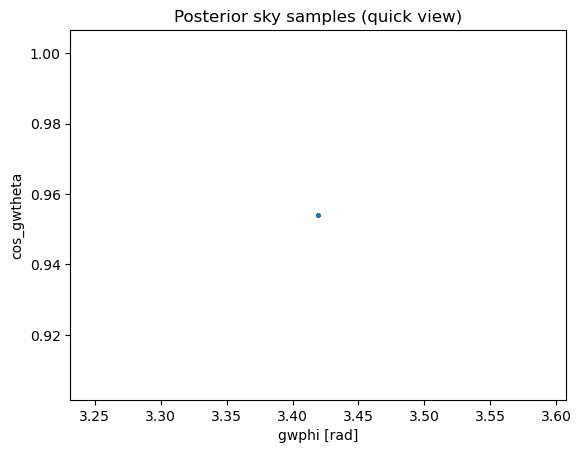

In [32]:
plt.figure()
plt.scatter(gwphi_samps, cos_gwtheta_samps, s=2, alpha=0.2)
plt.xlabel("gwphi [rad]")
plt.ylabel("cos_gwtheta")
plt.title("Posterior sky samples (quick view)")
plt.show()

In [ ]:
extra = mcmc.get_extra_fields()
n_div = int(extra["diverging"].sum()) if "diverging" in extra else None
print("divergences:", n_div)

divergences: 1200


In [ ]:
if "accept_prob" in extra:
    ap = np.array(extra["accept_prob"])
    print("accept_prob mean/std:", ap.mean(), ap.std())
if "tree_depth" in extra:
    td = np.array(extra["tree_depth"])
    print("tree_depth max/mean:", td.max(), td.mean())

In [ ]:
mcmc.print_summary()  # already prints ESS, and R-hat if multiple chains


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
 Param:0[0]      0.81      0.00      0.81      0.81      0.81      1.00      1.00
 Param:0[1]      3.00      0.00      3.00      3.00      3.00       nan       nan
 Param:0[2]    -20.00      0.00    -20.00    -20.00    -20.00       nan       nan
 Param:0[3]      3.05      0.00      3.05      3.05      3.05      1.00      1.00
 Param:0[4]      3.00      0.00      3.00      3.00      3.00       nan       nan
 Param:0[5]    -20.00      0.00    -20.00    -20.00    -20.00       nan       nan
 Param:0[6]      4.63      0.00      4.63      4.63      4.63      1.00      1.00
 Param:0[7]      3.00      0.00      3.00      3.00      3.00       nan       nan
 Param:0[8]    -20.00      0.00    -20.00    -20.00    -20.00       nan       nan
 Param:0[9]      0.57      0.00      0.57      0.57      0.57      1.00      1.00
Param:0[10]      3.00      0.00      3.00      3.00      3.00       nan       nan
Param:0[11]    

In [ ]:
samples = mcmc.get_samples()
if isinstance(samples, dict):
    samples_arr = samples[list(samples.keys())[0]]
else:
    samples_arr = samples

print("samples_arr shape:", samples_arr.shape)

samples_arr shape: (1200, 40)


In [ ]:
u_dist_samps = samples_arr[:, U_DIST_IDXS]
p_dist_samps = jax.nn.softplus(u_dist_samps) + EPS_DIST

pdist_mean = np.array(jnp.mean(p_dist_samps, axis=0))
pdist_std  = np.array(jnp.std(p_dist_samps, axis=0))

for name, mu, sd, mu0, sig0 in zip([p.name for p in disco_psrs], pdist_mean, pdist_std,
                                  np.array(dist_mu), np.array(dist_sig)):
    print(f"{name:12s}  p_dist={mu:6.3f}±{sd:6.3f} kpc   prior={mu0:6.3f}±{sig0:6.3f}")

B1855+09      p_dist= 1.180± 0.000 kpc   prior= 1.180± 0.120
B1937+21      p_dist= 3.100± 0.000 kpc   prior= 3.100± 0.200
B1953+29      p_dist= 4.640± 0.000 kpc   prior= 4.640± 0.930
J0023+0923    p_dist= 1.020± 0.000 kpc   prior= 1.020± 0.110
J0030+0451    p_dist= 0.330± 0.000 kpc   prior= 0.330± 0.004
J0125-2327    p_dist= 0.873± 0.000 kpc   prior= 0.873± 0.175
J0340+4130    p_dist= 1.710± 0.000 kpc   prior= 1.710± 0.340
J0406+3039    p_dist= 1.720± 0.000 kpc   prior= 1.720± 0.340
J0437-4715    p_dist= 0.155± 0.000 kpc   prior= 0.155± 0.001
J0509+0856    p_dist= 1.450± 0.000 kpc   prior= 1.450± 0.290


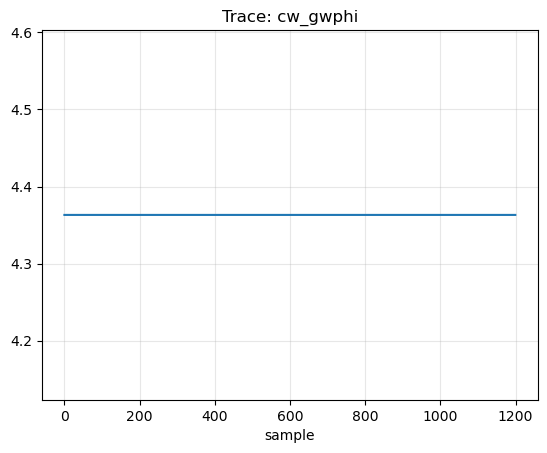

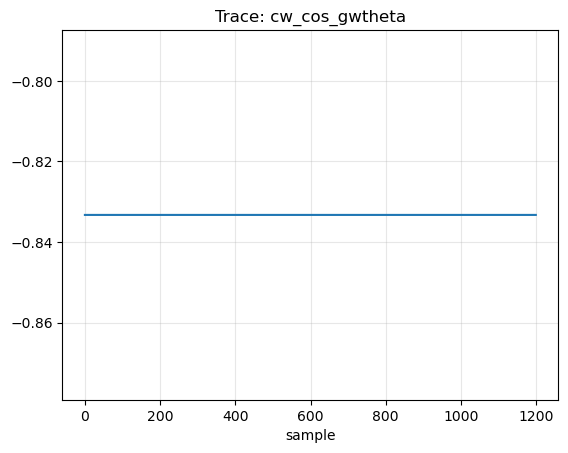

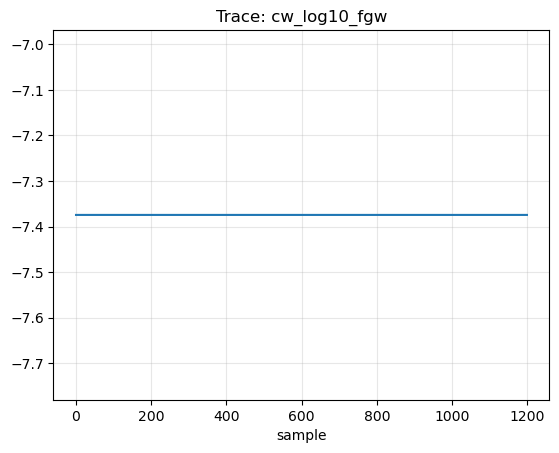

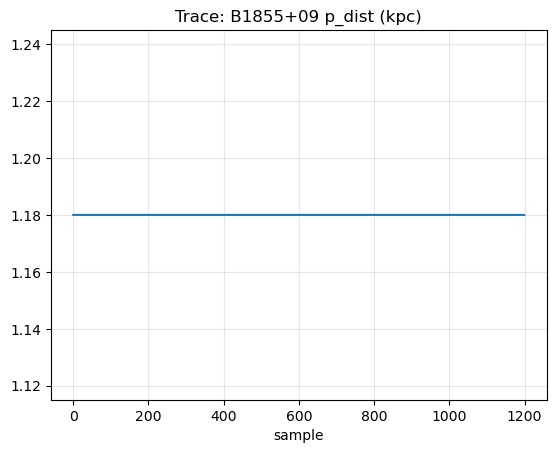

In [ ]:
def trace(idx, label):
    plt.figure()
    plt.plot(np.array(samples_arr[:, idx]))
    plt.title(f"Trace: {label}")
    plt.xlabel("sample")
    plt.grid(True, alpha=0.3)
    plt.show()

trace(IDX_GWPHI, "cw_gwphi")
trace(IDX_COSGWTHETA, "cw_cos_gwtheta")
trace(IDX_LOG10FGW, "cw_log10_fgw")

# one pulsar distance (physical)
plt.figure()
plt.plot(np.array(p_dist_samps[:, 0]))
plt.title(f"Trace: {disco_psrs[0].name} p_dist (kpc)")
plt.xlabel("sample")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def get_injected(discovery_key):
    ek = reverse_temp_dict.get(discovery_key, discovery_key)
    return enterprise_params.get(ek, None)

for k in ["cw_gwphi", "cw_cos_gwtheta", "cw_log10_fgw", "cw_log10_h", "cw_log10_mc"]:
    inj = get_injected(k)
    if inj is None:
        print(k, "no injection value found")
        continue
    idx = idx_map[k]
    vals = np.array(samples_arr[:, idx])
    print(f"{k}: posterior mean={vals.mean():.4g}, inj={inj:.4g}, std={vals.std():.4g}")

cw_gwphi: posterior mean=4.363, inj=4.363, std=0
cw_cos_gwtheta: posterior mean=-0.8333, inj=-0.8333, std=5.96e-08
cw_log10_fgw: posterior mean=-7.374, inj=-7.374, std=4.768e-07
cw_log10_h: posterior mean=-15.75, inj=-15.75, std=9.537e-07
cw_log10_mc: posterior mean=7.666, inj=7.666, std=4.768e-07


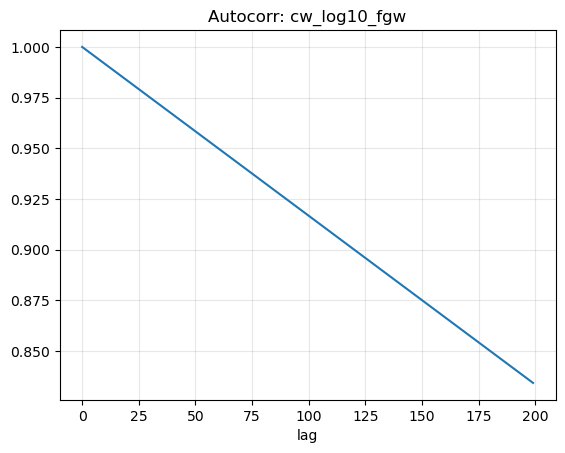

In [ ]:
def autocorr(x, max_lag=200):
    x = np.array(x)
    x = x - x.mean()
    ac = np.correlate(x, x, mode="full")[len(x)-1:]
    ac /= ac[0]
    return ac[:max_lag]

plt.figure()
plt.plot(autocorr(np.array(samples_arr[:, IDX_LOG10FGW]), 200))
plt.title("Autocorr: cw_log10_fgw")
plt.xlabel("lag")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(type(samples_arr), samples_arr.shape)
print("first row, first 10 entries:", np.array(samples_arr[0, :10]))
print("last row, first 10 entries:", np.array(samples_arr[-1, :10]))

<class 'jaxlib._jax.ArrayImpl'> (1200, 40)
first row, first 10 entries: [  0.812871    3.        -20.          3.0539033   3.        -20.
   4.6302943   3.        -20.          0.5727814]
last row, first 10 entries: [  0.812871    3.        -20.          3.0539033   3.        -20.
   4.6302943   3.        -20.          0.5727814]


In [ ]:
# variation check for a few parameters
def var_report(name):
    idx = idx_map[name]
    v = np.array(samples_arr[:, idx])
    print(name, "std:", v.std(), "min/max:", v.min(), v.max())

for name in ["cw_log10_fgw", "cw_gwphi", "cw_cos_gwtheta", "cw_log10_h"]:
    var_report(name)

cw_log10_fgw std: 4.7683716e-07 min/max: -7.374412 -7.374412
cw_gwphi std: 0.0 min/max: 4.363094 4.363094
cw_cos_gwtheta std: 5.9604645e-08 min/max: -0.8332533 -0.8332533
cw_log10_h std: 9.536743e-07 min/max: -15.750519 -15.750519


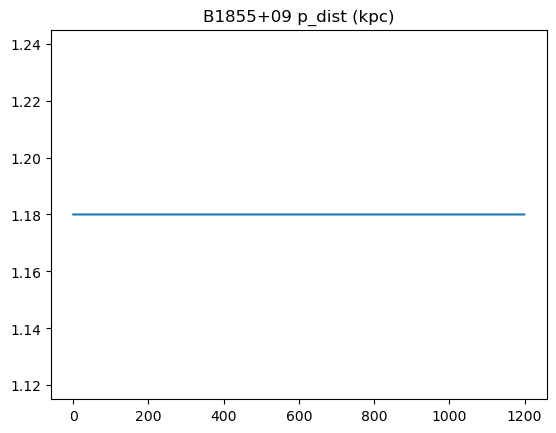

In [ ]:
plt.figure()
plt.plot(np.array(p_dist_samps[:, 0]))
plt.title(f"{disco_psrs[0].name} p_dist (kpc)")
plt.show()

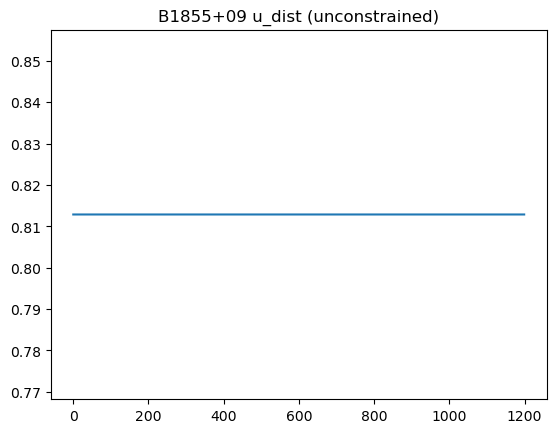

In [ ]:
plt.figure()
plt.plot(np.array(u_dist_samps[:, 0]))
plt.title(f"{disco_psrs[0].name} u_dist (unconstrained)")
plt.show()

In [ ]:
def quarter_means(name):
    idx = idx_map[name]
    v = np.array(samples_arr[:, idx])
    qs = np.array_split(v, 4)
    print(name, [q.mean() for q in qs], "overall std", v.std())

for name in ["cw_log10_fgw", "cw_gwphi", "cw_cos_gwtheta", "cw_log10_h"]:
    quarter_means(name)

cw_log10_fgw [np.float32(-7.3744116), np.float32(-7.3744116), np.float32(-7.3744116), np.float32(-7.3744116)] overall std 4.7683716e-07
cw_gwphi [np.float32(4.363094), np.float32(4.363094), np.float32(4.363094), np.float32(4.363094)] overall std 0.0
cw_cos_gwtheta [np.float32(-0.8332533), np.float32(-0.8332533), np.float32(-0.8332533), np.float32(-0.8332533)] overall std 5.9604645e-08
cw_log10_h [np.float32(-15.750518), np.float32(-15.750518), np.float32(-15.750518), np.float32(-15.750518)] overall std 9.536743e-07


In [ ]:
vals = np.array(samples_arr[:, IDX_LOG10FGW])
vals2 = vals[len(vals)//2:]
print("log10_fgw mean first half / second half:", vals[:len(vals)//2].mean(), vals2.mean())

log10_fgw mean first half / second half: -7.3744125 -7.3744125
